# Temporal Evolution of Privilege Ratio

How the privilege ratio (% of + rules) evolves across 5 periods. Split into demographic and social status groups. Above 50% = more privileged, below = more excluded.

In [1]:
import json, re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.dpi'] = 150

GEMINI_DIR = Path("../data/llm_results/gemini_v18")
sample = pd.read_csv("../data/perseus_works_wikidata_sample.tsv", sep="\t")

# Load all rules
all_rows = []
for fp in GEMINI_DIR.glob("tlg*.json"):
    with open(fp) as f: data = json.load(f)
    fid = data.get("_file_id", fp.stem)
    meta = sample[sample["file_id"] == fid]
    if len(meta) == 0: continue
    m = meta.iloc[0]
    for r in data.get("extracted_rules", []):
        if not isinstance(r, dict): continue
        all_rows.append({"author": m["perseus_author"], "group": str(r.get("group","")).strip(),
            "group_category": str(r.get("group_category","")).strip(),
            "resource_category": str(r.get("resource_category","")).strip(),
            "rule_category": str(r.get("rule_category","")).strip(),
            "direction": str(r.get("directionality","")).strip().upper(),
            "author_impact_date": m["author_impact_date"], "file_id": fid, "n_pages": m["n_pages"]})

df = pd.DataFrame(all_rows)

# Harmonize groups
def harmonize_who(v):
    s = str(v).strip().lower()
    if re.search(r"wom[ae]n|female|wife|maiden|widow|mother|daughter", s): return "Women"
    if re.search(r"slav|enslav|servil|bondage|unfree|helot", s): return "Slaves"
    if re.search(r"non.?citizen|metic|foreigner|resident alien|stranger|exile|immigrant", s): return "Non-citizens"
    if re.search(r"citizen|full citiz", s): return "Citizens"
    if re.search(r"poor|propertyless|destitut|landless", s): return "The poor"
    if re.search(r"wealth|rich|affluent|propert", s): return "The wealthy"
    if re.search(r"noble|aristocrat|highborn|royal|king|prince", s): return "Nobility"
    if re.search(r"common|lowborn|base.?born|non.?noble|peasant", s): return "Commoners"
    if re.search(r"young|youth|child|minor|infant|boy|girl", s): return "Young/Children"
    if re.search(r"elder|old\b|elderly|aged|senior", s): return "Elders"
    if re.search(r"barbarian|ethnic|non.?greek", s): return "Barbarians"
    if re.search(r"soldier|warrior|military|veteran", s): return "Soldiers"
    if re.search(r"priest|priestess|clergy", s): return "Priests"
    if re.search(r"^men$|^male|husband|adult men|free men", s): return "Men"
    if re.search(r"disabled|sick|ill\b|blind|deaf", s): return "Disabled/Sick"
    return None

df["who_h"] = df["group"].apply(harmonize_who)
df = df[df["who_h"].notna() & df["resource_category"].notna() & (df["resource_category"] != "")]
df = df[pd.to_numeric(df["author_impact_date"], errors="coerce").notna()]
df["year"] = df["author_impact_date"].astype(int)

def period(y):
    if y <= -480: return "Archaic"
    elif y <= -360: return "Classical Athens"
    elif y <= -165: return "Late Classical"
    elif y <= 105: return "Hellenistic"
    else: return "High Roman"

df["period"] = df["year"].apply(period)
dedup = df.drop_duplicates(subset=["author", "who_h", "resource_category", "direction"])
print(f"Loaded {len(df):,} raw rules, {len(dedup):,} deduplicated, from {df['file_id'].nunique()} works")

Loaded 3,636 raw rules, 1,438 deduplicated, from 85 works


## Setup styles and plot function

In [2]:
from adjustText import adjust_text

period_order = ["Archaic", "Classical Athens", "Late Classical", "Hellenistic", "High Roman"]
period_labels = ["Archaic\n750\u2013480 BCE", "Classical Athens\n465\u2013360 BCE", "Late Classical\n354\u2013165 BCE",
                 "Hellenistic\n165 BCE\u2013105 CE", "High Roman\n135\u2013205 CE"]

demo_styles = {"Women": {"color":"#c0392b","marker":"o","ms":11,"lw":3,"ls":"-"}, "Men": {"color":"#2980b9","marker":"s","ms":10,"lw":3,"ls":"-"},
    "Young/Children": {"color":"#e67e22","marker":"D","ms":9,"lw":2.5,"ls":"--"}, "Elders": {"color":"#8e44ad","marker":"^","ms":11,"lw":2.5,"ls":"--"},
    "Disabled/Sick": {"color":"#27ae60","marker":"v","ms":10,"lw":2,"ls":"-."}}
status_styles = {"Citizens": {"color":"#2980b9","marker":"o","ms":11,"lw":3,"ls":"-"}, "Soldiers": {"color":"#1abc9c","marker":"s","ms":10,"lw":3,"ls":"-"},
    "The poor": {"color":"#f39c12","marker":"P","ms":11,"lw":2.5,"ls":"--"}, "Non-citizens": {"color":"#d35400","marker":"D","ms":9,"lw":2.5,"ls":"--"},
    "Slaves": {"color":"#c0392b","marker":"^","ms":11,"lw":3,"ls":"-"}, "The wealthy": {"color":"#27ae60","marker":"v","ms":10,"lw":2.5,"ls":"-."},
    "Nobility": {"color":"#3498db","marker":"h","ms":11,"lw":2,"ls":"-."}}

def plot_temporal(groups, styles):
    records = []
    for p in period_order:
        for who in groups:
            wsub = dedup[(dedup["period"]==p) & (dedup["who_h"]==who)]
            more, less = len(wsub[wsub["direction"]=="MORE"]), len(wsub[wsub["direction"]=="LESS"])
            total = more+less
            records.append({"period": p, "who": who, "ratio": (100-less/total*100) if total>=10 else np.nan})
    pivot = pd.DataFrame(records).pivot(index="who", columns="period", values="ratio")[period_order]
    pivot = pivot[pivot.notna().sum(axis=1) >= 2]
    pivot["mean"] = pivot.mean(axis=1); pivot = pivot.sort_values("mean", ascending=False).drop(columns="mean")
    fig, ax = plt.subplots(figsize=(14, 9)); x = np.arange(len(period_order)); texts = []
    for who in pivot.index:
        vals = pivot.loc[who].values; s = styles.get(who)
        if not s: continue
        valid = ~np.isnan(vals)
        ax.plot(x[valid], vals[valid], marker=s["marker"], markersize=s["ms"], linewidth=s["lw"], color=s["color"],
                alpha=0.95, linestyle=s["ls"], markeredgecolor="white", markeredgewidth=1.5, zorder=3, label=who)
        for idx in range(len(vals)-1,-1,-1):
            if not np.isnan(vals[idx]):
                texts.append(ax.annotate(who, xy=(x[idx],vals[idx]), xytext=(x[idx]+0.3,vals[idx]),
                    fontsize=14, fontweight="700", color=s["color"], va="center", ha="left")); break
    adjust_text(texts, ax=ax, only_move={"text":"y"}, arrowprops=dict(arrowstyle="-",color="#ccc",lw=0.8), force_text=(0.2,2), min_arrow_len=5)
    ax.axhline(50, color="#1d1d1f", linewidth=1.5, linestyle="--", alpha=0.3)
    ax.axhspan(50,105,color="#e8f4f8",alpha=0.5,zorder=0); ax.axhspan(-5,50,color="#fdf2f2",alpha=0.5,zorder=0)
    ax.text(0.02,0.92,"More privileged",transform=ax.transAxes,fontsize=13,fontweight="600",color="#2c6e91",alpha=0.6)
    ax.text(0.02,0.06,"More excluded",transform=ax.transAxes,fontsize=13,fontweight="600",color="#c0392b",alpha=0.6)
    ax.set_xticks(x); ax.set_xticklabels(period_labels, fontsize=13, fontweight="600")
    ax.set_ylabel("Privilege ratio %", fontsize=14, fontweight="600", color="#444")
    ax.set_ylim(-2,102); ax.set_xlim(-0.3,len(period_order)-0.7)
    ax.set_yticks([0,25,50,75,100]); ax.set_yticklabels(["0%","25%","50%","75%","100%"], fontsize=13)
    ax.grid(axis="y",alpha=0.3,linestyle="--",zorder=0); ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.legend(loc="center left", bbox_to_anchor=(1.02,0.5), fontsize=14, frameon=True, framealpha=0.95)
    plt.tight_layout(); plt.show()

## Demographic groups

Women, Men, Young/Children, Elders, Disabled/Sick

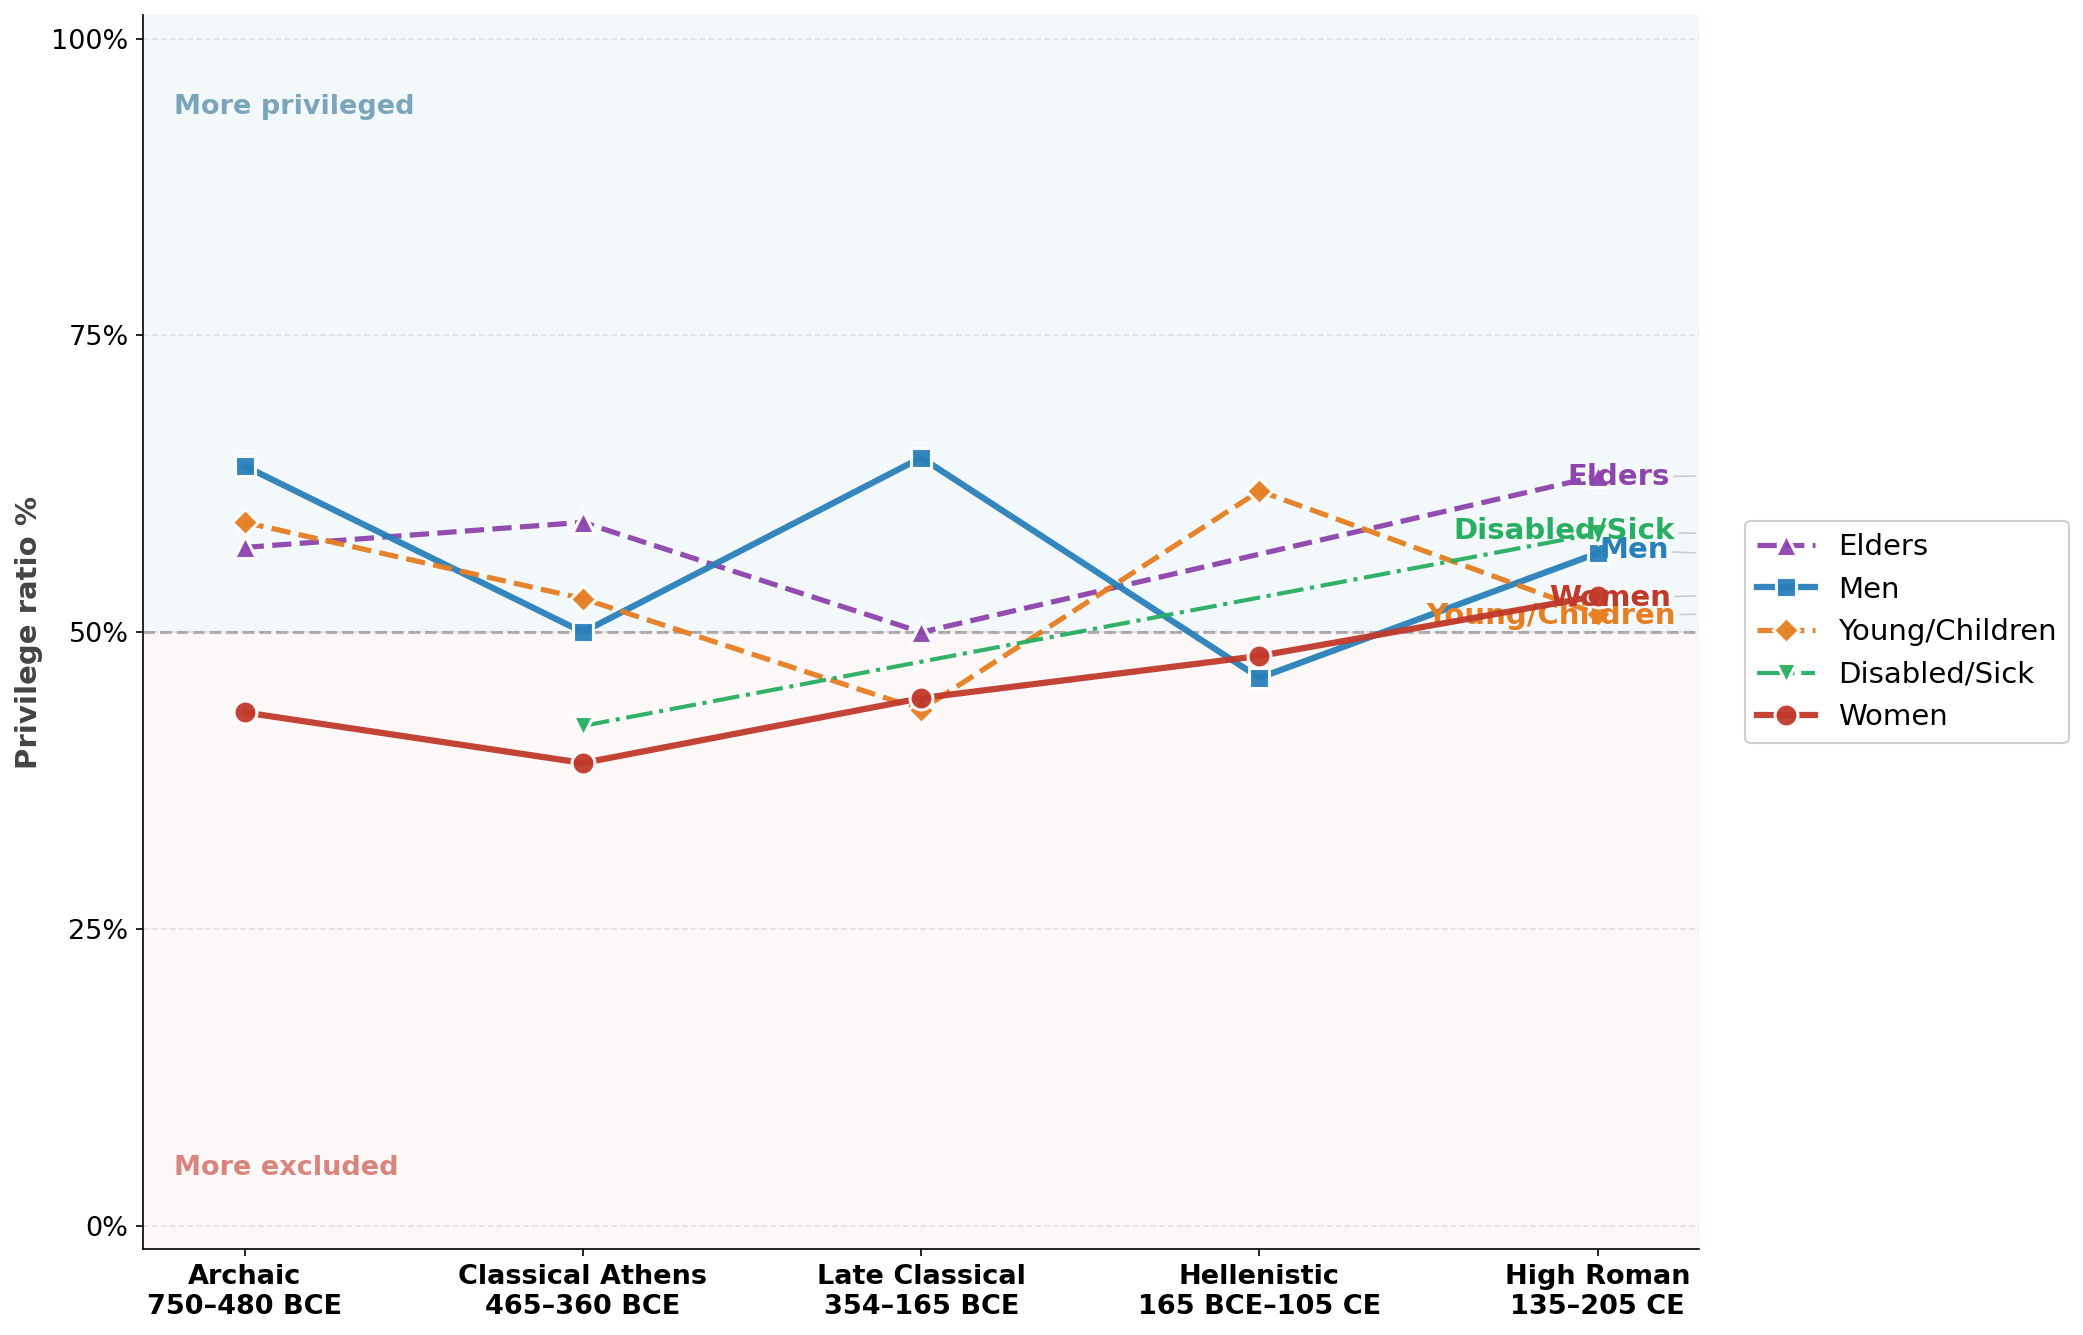

In [3]:
plot_temporal(["Women", "Men", "Young/Children", "Elders", "Disabled/Sick"], demo_styles)

## Social status groups

Citizens, Non-citizens, Slaves, Nobility, The wealthy, The poor, Soldiers

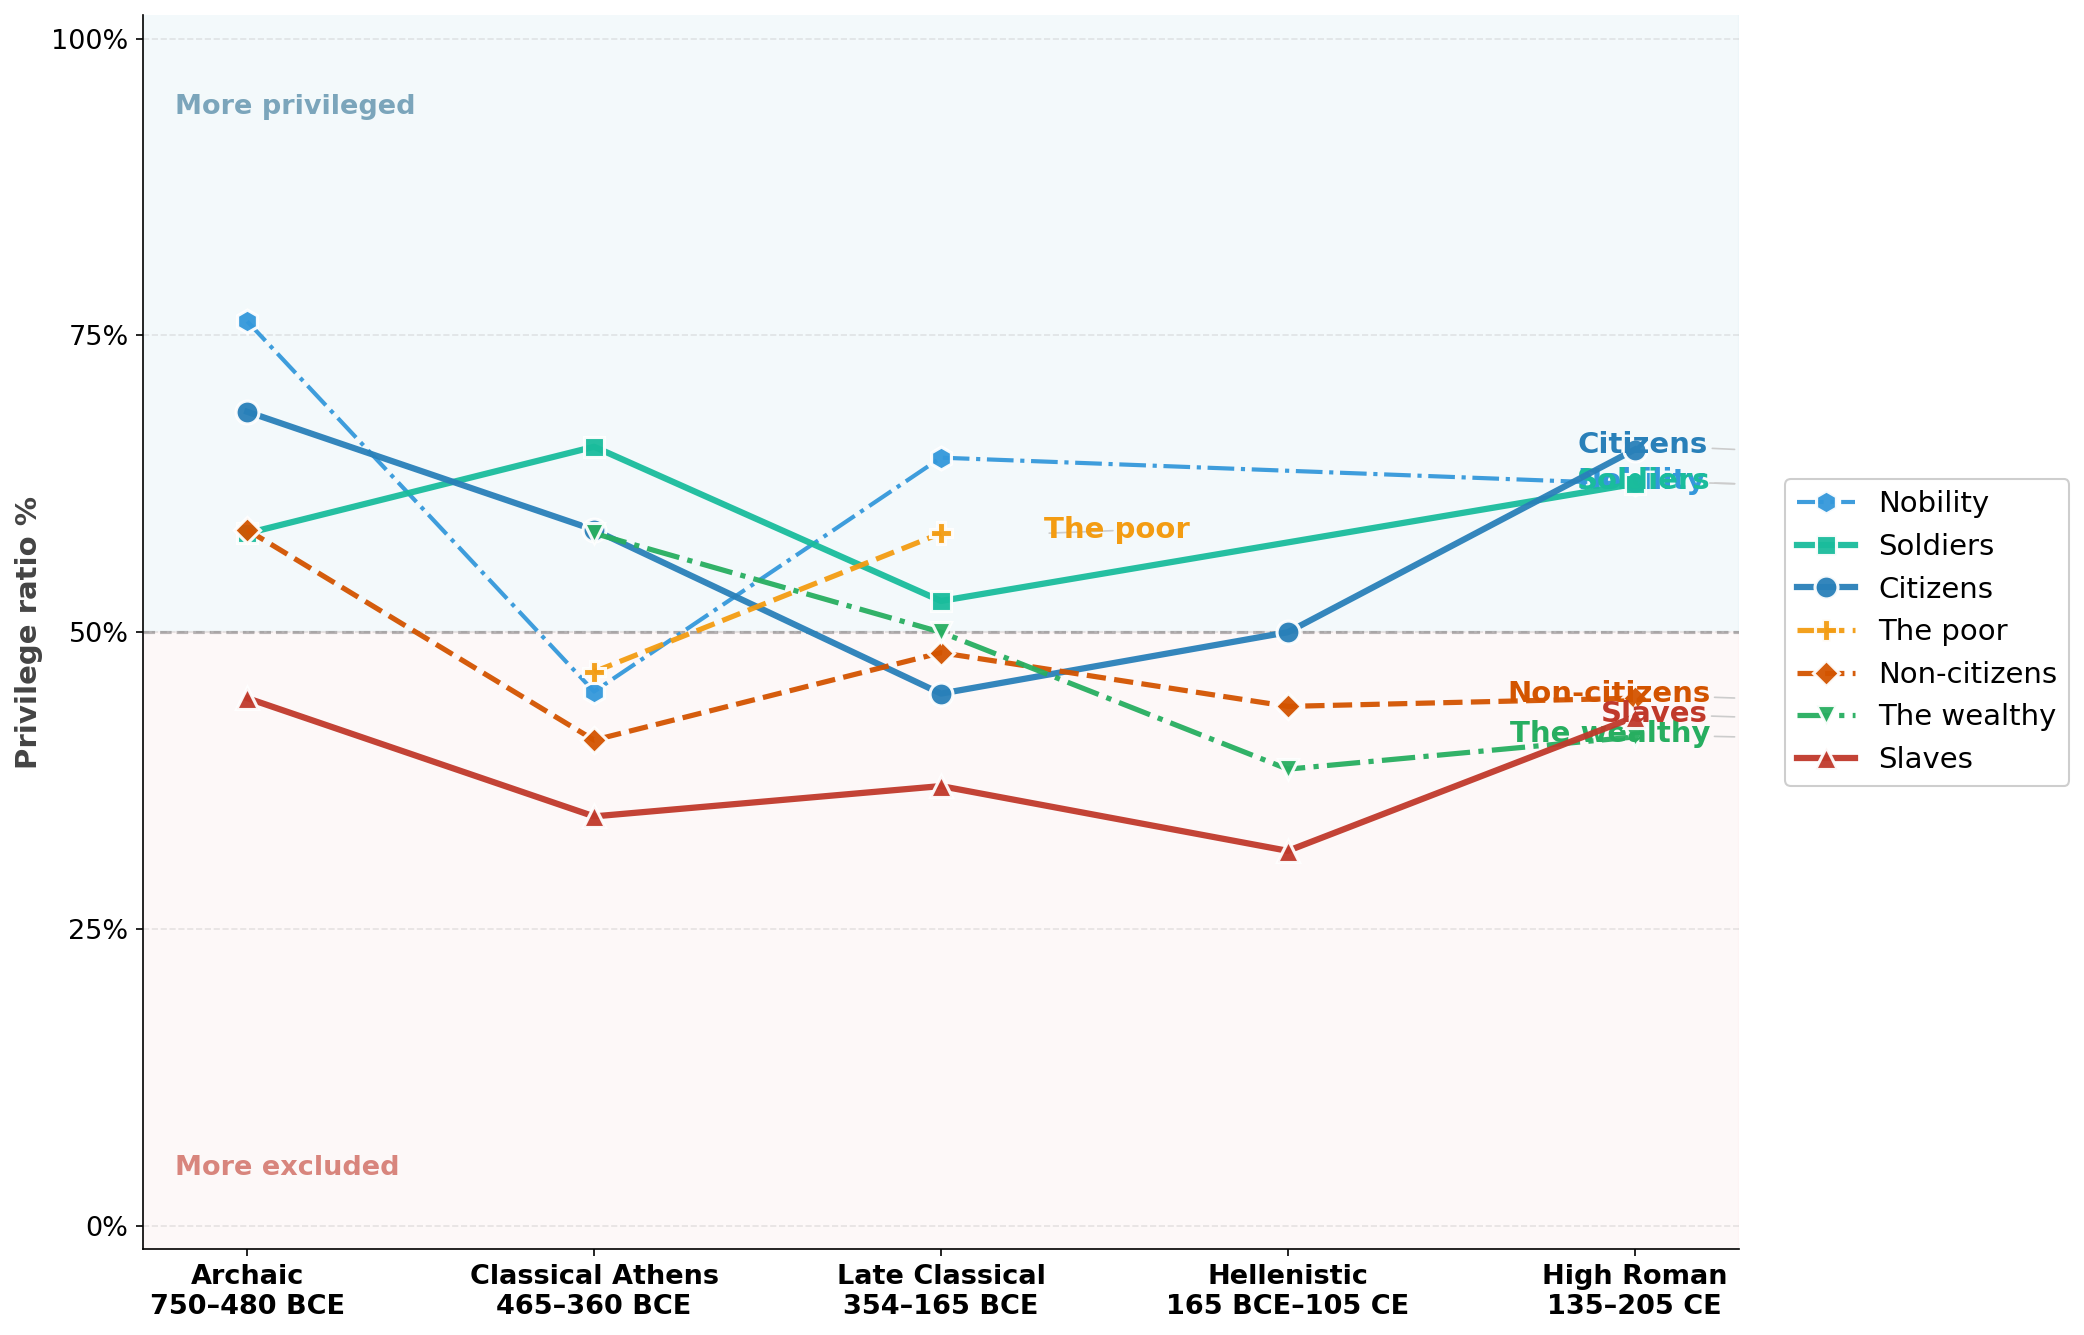

In [4]:
plot_temporal(["Citizens", "Non-citizens", "Slaves", "Nobility", "The wealthy", "The poor", "Soldiers"], status_styles)